# <center>**Resultados 01**:<br>Código que estuda as equações de taxa<center>


A primeira parte dos resultados é a análise do sistema

$$\begin{equation}
	\left\{\begin{array}{rl}
    \dot{N}_1 &= W_p(N_3 - N_1) + W_l(N_2 - N_1) + T_{21 }N_2\\[.4cm]
	\dot{N}_2 &= W_l(N_1 - N_2) + T_{32}N_3 - T_{21} N_2\\[.4cm]
	\dot{N}_3 &= W_p(N_1 - N_3) - T_{32}N_3
    \end{array}\right.
\end{equation}$$

As equações acima descrevem um sistema laser de três níveis a partir das equações de taxa. No TCC, esse código está referenciado como *"Código 01"*.

## **01.** Comandos iniciais do código

**Versão:** 1.3<br>
**Data de criação:** 27/01/2026<br>
**Criado por:** Jimi (Willian Bonner)<br>

Os comandos iniciais do cógidos são as bibliotecas que utilizamos nas análises e para gerar os códigos. Além disso, configuram a estética dos gráficos.

**Essa seção do código faz:**
1. *Insere os parâmetros físicos do laser de rubi;*
2. *Reescalona o tempo e faz calculos com o sistema reescalonado;*
3. *Calcula os pontos fixos;*
4. *Análisa a estabilidade dos pontos fixos;*
5. *Faz a resolução numérica com o método adequado para sistemas com Stiff;*
6. *Insere condições iniciais no plano de fase;*
7. *Plota o plano de fases;*
8. *Plota a evolução temporal das populações $N_1$ e $N_2$ .*

In [2]:
#comandos para deixar as imagens com fonte Times (fonte de gente normal)
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import warnings
import sympy as sy
from gravipy.tensorial import *
import math
from IPython.display import display, Math, Latex
warnings.filterwarnings('ignore')

# Configuração do LaTeX
plt.rcParams.update({"text.usetex": True,"font.family": "serif","font.serif": ["Times"],
                     "text.latex.preamble": r"""\usepackage{amsmath}\usepackage{amssymb}
                     \usepackage{physics}
                     \usepackage{times}"""})

print('='*80)
display(Math(r'\LaTeX\ está\ ativo!'))
print('='*80)

<IPython.core.display.Math object>

## **02.** Código para análise numérica do sistema

In [3]:
# ============================================
# Análise numérica do sistema
# Autor: Jimi (Willian Bonner)
# Data de criação: 31/01/2026
# Versão: 1.3
# ============================================

# 1. Parâmetros físicos do sistema laser (rubi)

# Valores em s^-1
W_p = 1e4      # Taxa de bombeamento óptico (10^4 s^-1)
W_l = 1e9      # Taxa de relaxação não radiativa 3→2 (10^9 s^-1)
T_21 = 333     # Taxa de emissão 2→1 (1/3ms ≈ 333 s^-1)
T_32 = 1e9     # Taxa de relaxação 3→2 (10^9 s^-1)
N_total = 1    # População total normalizada

print("="*60)
print("Parâmetros físicos (s^-1):")
print(f"W_p = {W_p:.2e}")
print(f"W_l = {W_l:.2e}")
print(f"T_21 = {T_21:.2e}")
print(f"T_32 = {T_32:.2e}")
print(f"N_total = {N_total:.2e}")


# 2. Adimensionalização dos parâmetros

# 2.1 Adimensionaliza-se o sistema pelo tempo característico mais lento (T_21^-1 ≈ 3ms)

t_scale = T_21  # Fator de escala para tempo adimensional
print(f"Fator de escala temporal: {t_scale:.1e} s^-1")
print("="*60)

# 2.2 Parâmetros adimensionais

wp = W_p / t_scale
wl = W_l / t_scale
t21 = T_21 / t_scale  # = 1
t32 = T_32 / t_scale

print("\n1. Parâmetros adimensionais:")
print(f"wp = {wp:.2e}")
print(f"wl = {wl:.2e}")
print(f"t21 = {t21:.2e}")
print(f"t32 = {t32:.2e}")


# 3. Sistema adimensionalizado

def sistema_reescalonado(tau, y, wp, wl, t21, t32, N):
    """Sistema reescalonado em tempo adimensional τ"""
    N1, N2 = y
    N3 = N - N1 - N2
    
    # Equações reescalonadas
    dN1_dtau = wp * (N3 - N1) + wl * (N2 - N1) + t21 * N2
    dN2_dtau = wl * (N1 - N2) + t32 * N3 - t21 * N2
    
    return [dN1_dtau, dN2_dtau]


# 4. Cálculo dos pontos de equilíbrio do sistema

# 4.1 Resolvendo sistema linear para o equilíbrio pela matriz do sistema reduzido

B = np.array([
    [-(2*wp + wl), wl + t21 - wp],
    [wl - t32, -(wl + t32 + t21)]
])
c = np.array([wp * N_total, t32 * N_total])

# 4.2 Ponto de equilíbrio

try:
    N_star = -np.linalg.solve(B, c)
    N1_star, N2_star = N_star
    N3_star = N_total - N1_star - N2_star
    print(f"\n2. Ponto de equilíbrio adimensional:")
    print(f"N1* = {N1_star:.2f}")
    print(f"N2* = {N2_star:.2f}")
    print(f"N3* = {N3_star:.2f}")
    
    # Verificação de viabilidade
    if N1_star < 0 or N2_star < 0 or N3_star < 0:
        print("AVISO: Ponto de equilíbrio não é fisicamente viável!")
except np.linalg.LinAlgError:
    print("Erro: Matriz singular. Usando aproximação adiabática...")
    # Aproximação adiabática para nível 3 (N3 ≈ 0)
    N1_star = (wl * N_total) / (wp + wl)
    N2_star = (wp * N_total) / (wp + wl)
    N3_star = 0

# 5. Análise de Estabilidade

eigenvals, eigenvecs = np.linalg.eig(B)
print(f"\n3. Autovalores do sistema reescalonado:")
print(f"λ₁ = {eigenvals[0]:.2e}")
print(f"λ₂ = {eigenvals[1]:.2e}")

# 6. Identificar tipo de equilíbrio

if np.iscomplex(eigenvals[0]):
    freq = np.abs(np.imag(eigenvals[0])) / (2*np.pi)
    print(f"Frequência característica: {freq:.2e}")
    print("Tipo: Foco estável (oscilações amortecidas)")
else:
    print("Tipo: Nó estável (convergência exponencial)")

Parâmetros físicos (s^-1):
W_p = 1.00e+04
W_l = 1.00e+09
T_21 = 3.33e+02
T_32 = 1.00e+09
N_total = 1.00e+00
Fator de escala temporal: 3.3e+02 s^-1

1. Parâmetros adimensionais:
wp = 3.00e+01
wl = 3.00e+06
t21 = 1.00e+00
t32 = 3.00e+06

2. Ponto de equilíbrio adimensional:
N1* = 0.50
N2* = 0.50
N3* = 0.00

3. Autovalores do sistema reescalonado:
λ₁ = -3.00e+06
λ₂ = -6.01e+06
Tipo: Nó estável (convergência exponencial)


## **03.** Código que gera o espaço de fases

O código que gera o espaços de fase possui um núcleo que realiza a simulação numérica antes de plotar o plano de fases. Optamos por deixar a análise separada para que seja mais fácil identificar possíveis erros.

### <center>**1.2.1** Núcleo do código (*faz os cálculos numéricos*)<center>

Para resolver o sistema stiff, utilizamos o método *Radau*.

In [4]:
# =========================================================================
# Código para simulação numérica do sitema.
# Autor: Jimi (Willian Bonner)
# Data de criação: 31/01/2026
# Versão 1.3
# =========================================================================

# 1. Função que faz a análise

def simular_trajetoria(N1_0, N2_0, tempo_final=10):
    # 1.2 Verificar viabilidade inicial
    
    if N1_0 + N2_0 > N_total:
        print(f"Condição inicial inviável: N1+N2 = {N1_0+N2_0:.3f} > {N_total}")
        return None
    
    # 1.3 Converter tempo final para escala adimensional
    tau_final = tempo_final * t_scale
    
    # 1.4 Usar solver stiff para problemas com escalas de tempo muito diferentes
    sol = solve_ivp(
        sistema_reescalonado,
        [0, tau_final],
        [N1_0, N2_0],
        args=(wp, wl, t21, t32, N_total),
        method='Radau',  # Método para sistemas stiff
        rtol=1e-8,
        atol=1e-10,
        dense_output=True,
        max_step=0.1*tau_final  # Limitar passo máximo
    )

    # 1.5 Mensagem de falha
    
    if not sol.success:
        print('='*60)
        print(f"Aviso: Integração não convergiu. Mensagem: {sol.message}")
        print('='*60)
    return sol

# 1.7 Mensagem de sucesso
print('='*60)
print('Integração numérica concluida com sucesso.')
print('='*60)

Integração numérica concluida com sucesso.


## **04.** Parte do código que gera o espaço de fases


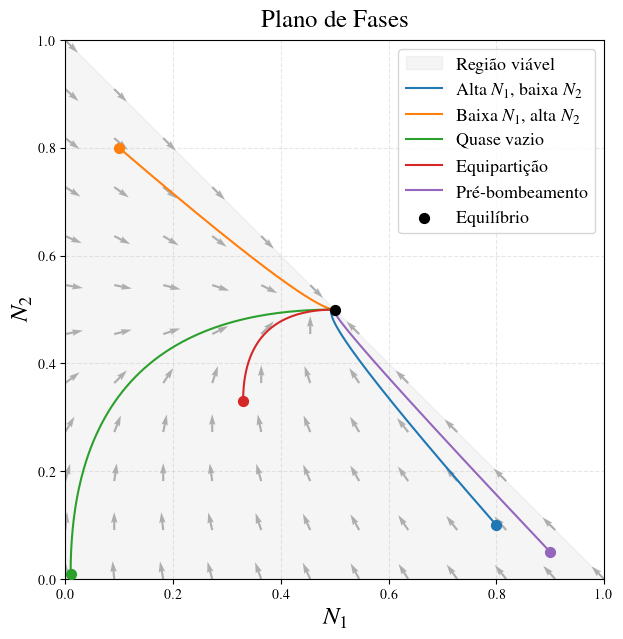

In [5]:
# =========================================================================
# Código para plotar o espaço de fases.
# Autor: Jimi (Willian Bonner)
# Data de criação: 31/01/2026
# Versão 1.3
# =========================================================================

# 1. Condições iniciais

condicoes_iniciais = [
    [0.8, 0.1, r"Alta $N_1$, baixa $N_2$"],    # Quase todo mundo no nível 1
    [0.1, 0.8, r"Baixa $N_1$, alta $N_2$"],    # Quase todo mundo no nível 2
    [0.01, 0.01, r"Quase vazio"],              # Quase todos no nível 3
    [0.33, 0.33, r"Equipartição"],            # Distribuição igual
    [0.9, 0.05, r"Pré-bombeamento"]            # Condição típica de laser
]

# 2. Espaço de fases com trajetórias

fig, (ax1) = plt.subplots(1, figsize=(7, 7))
ax1.set_title(r'Plano de Fases', fontsize=18, pad=10)
ax1.set_xlabel(r'$N_1$', fontsize=18)
ax1.set_ylabel(r'$N_2$', fontsize=18)

# 2.1 Região viável (triângulo) - Para fins estéticos

triangulo = plt.Polygon([[0, 0], [N_total, 0], [0, N_total]], 
                        alpha=0.08, color='gray', label='Região viável')
ax1.add_patch(triangulo)

# 3. Campo vetorial reescalonado com setas normalizadas para melhorar a visualização

N1_grid = np.linspace(0, N_total, 12)
N2_grid = np.linspace(0, N_total, 12)
N1_mesh, N2_mesh = np.meshgrid(N1_grid, N2_grid)

U = np.zeros_like(N1_mesh)
V = np.zeros_like(N2_mesh)

for i in range(len(N1_grid)):
    for j in range(len(N2_grid)):
        if N1_grid[i] + N2_grid[j] <= N_total:
            deriv = sistema_reescalonado(0, [N1_grid[i], N2_grid[j]], 
                                         wp, wl, t21, t32, N_total)
            U[j, i] = deriv[0]
            V[j, i] = deriv[1]
        else:
            U[j, i] = np.nan
            V[j, i] = np.nan

norm = np.sqrt(U**2 + V**2)
norm[norm == 0] = 1  # Evitar divisão por zero
U_norm = U / norm
V_norm = V / norm 

N1_range = np.linspace(0, 0.5, 100)
N2_fixed =  N1_range

ax1.quiver(N1_mesh, N2_mesh, U_norm, V_norm, color='gray', alpha=0.6, scale=30, width=0.004)
#plt.streamplot(N1_mesh, N2_mesh, U_norm, V_norm, color='black', density=1.5, linewidth=0.5, arrowsize=0.6, broken_streamlines=True)

# 4. Simular e plotar trajetórias
cores = plt.cm.tab10.colors
for idx, (N1_0, N2_0, label) in enumerate(condicoes_iniciais):
    sol = simular_trajetoria(N1_0, N2_0, tempo_final=1e-3)  # 1ms em tempo real
    
    if sol is not None:
        # Converter tempo de volta para segundos
        t_segundos = sol.t / t_scale
        
        # Plotar trajetória
        ax1.plot(sol.y[0], sol.y[1], color=cores[idx], 
                linewidth=1.5, label=label)
        ax1.scatter(sol.y[0][0], sol.y[1][0], color=cores[idx], 
                   s=50, zorder=5)

# 5. Ponto de equilíbrio e configurações finais do plot

ax1.scatter(N1_star, N2_star, color='black', s=50, marker='o', zorder=10, label='Equilíbrio')#, edgecolor='black')
ax1.set_xlim(0, N_total)
ax1.set_ylim(0, N_total)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper right', fontsize=13)
ax1.set_aspect('equal')
plt.savefig("aef1.pdf",dpi=300, transparent=True,bbox_inches='tight')

## **05.** Plot da evolução temporal de $N_1$, $N_2$ e $N_3$

Valores finais das populações

Valor final de N1: 0.50
Valor final de N2: 0.50
Valor final de N3: 0.00


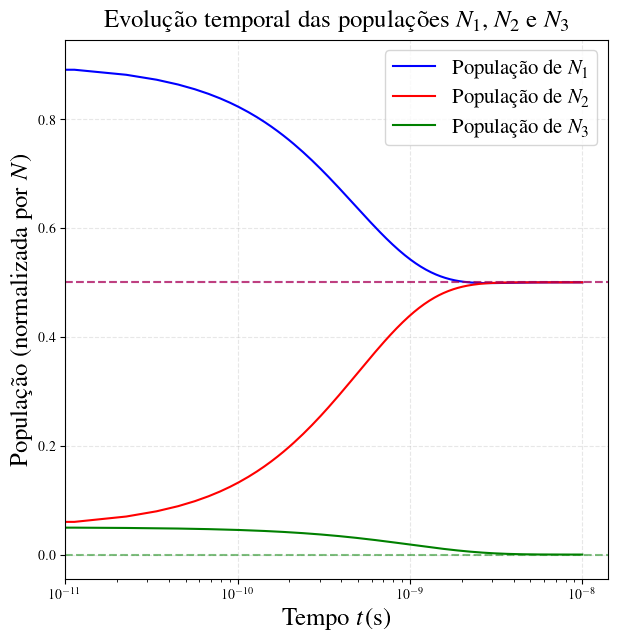

In [6]:
# =========================================================================
# Código para plotar a evolução temporal das populações N1 e N2.
# Autor: Jimi (Willian Bonner)
# Data de criação: 31/01/2026
# Versão 1.3
# =========================================================================

# 1. Gerar o gráfico e configurar seu tamanho

fig, (ax2) = plt.subplots(1, figsize=(7, 7))

# 2. Configuração de exibição dos eixos coordenados

ax2.set_title(r'Evolução temporal das populações $N_1$, $N_2$ e $N_3$', fontsize=18, pad=10)
ax2.set_xlabel(r'Tempo $t$(s)', fontsize=18)
ax2.set_ylabel(r'População (normalizada por $N$)', fontsize=18)

# 3. Simular evolução populacional (com detalhe na escala rápida)

sol_rapida = simular_trajetoria(0.9, 0.05, tempo_final=1e-8)  # 10 ns
if sol_rapida is not None:
    t_seg_rapida = sol_rapida.t / t_scale
    ax2.plot(t_seg_rapida, sol_rapida.y[0], 'b-', linewidth=1.5, label=r'População de $N_1$')
    ax2.plot(t_seg_rapida, sol_rapida.y[1], 'r-', linewidth=1.5, label=r'População de $N_2$')
    ax2.plot(t_seg_rapida, N_total - sol_rapida.y[0] - sol_rapida.y[1], 
            'g-', linewidth=1.5, label=r'População de $N_3$')

# 4. Configuração final do gráfico

ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', fontsize=15)
ax2.axhline(N1_star, color='blue', linestyle='--', alpha=0.5, label='$N_1^*$')
ax2.axhline(N2_star, color='red', linestyle='--', alpha=0.5, label='$N_2^*$')
ax2.axhline(N3_star, color='green', linestyle='--', alpha=0.5, label='$N_2^*$')
ax2.set_xscale('log')
ax2.set_xlim(left=1e-11)  # Evitar valores muito próximos de zero

# 5. Imprimir valores finais no console
print('='*60)
print('Valores finais das populações\n')
print(f"Valor final de N1: {sol_rapida.y[0, -1]:.2f}")
print(f"Valor final de N2: {sol_rapida.y[1, -1]:.2f}")
print(f"Valor final de N3: {N_total - sol_rapida.y[0, -1] - sol_rapida.y[1, -1]:.2f}")
print('='*60)

# 6. Salvar a figura como .pdf

plt.savefig("at1.pdf",dpi=300, transparent=True,bbox_inches='tight')

## **06.** Verificação final

Antes de subir o código para o Github, fiz um teste de compilação utilizando o Jupyter Notebook do Anaconda Navigator em 13 de Março de 2026.

Está tudo funcionando corretamente.